# <span style="color:green">Prueba - Análisis estadístico con Python</span>

La OMS estima que cada año se producen 12 millones de muertes en todo el mundo debido
a enfermedades cardíacas, producidas en su gran mayoría por enfermedades
cardiovasculares. El pronóstico temprano de las enfermedades cardiovasculares puede
ayudar en la toma de decisiones sobre cambios en el estilo de vida en pacientes de alto
riesgo y reducir las complicaciones.

La base de datos cardio.csv contiene mediciones realizadas a pacientes hace 10 años, entre
los cuales se encuentran

● Sex: M - F

● Age: edad

● Education: codificada, considerando que un valor más alto corresponde a un mayor
nivel educativo.

● currentSmoker: si el paciente es o no fumador actual

● cigsPerDay: el número de cigarrillos que la persona fumaba en promedio en un día.

● BPMeds: si el paciente estaba tomando medicamentos para la presión arterial (0: No,
1: Sí)

● prevalenStroke: si el paciente había tenido un accidente cerebrovascular previamente
(0: No, 1: Sí)

● prevalentHyp:: si el paciente era hipertenso o no (0: No, 1: Sí)

● diabetes: si el paciente tenía diabetes o no (0: No, 1: Sí)

● totChol: nivel de colesterol total

● sysBP: presión arterial sistólica

● diaBP_BMI: presión arterial diastólica

● BMI: Índice de masa corporal

● heartRate: : ritmo cardíaco

● glucose: nivel de glucosa

● TenYearCHD: se indica si el paciente sufrió o no una enfermedad coronaria en los
últimos 10 años.(0: No, 1: Sí)

# Librerias

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.metrics import r2_score, mean_squared_error, classification_report, roc_auc_score
import warnings

### Carga los datos y explóralos. Elimina los datos nulos o incorrectos

In [75]:
# Cargar el dataset
df = pd.read_csv('/home/sebastian/Desktop/hola/cardio.csv')

# Mostrar las primeras filas
print("Primeras 5 filas:")
df.head()

Primeras 5 filas:


,sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,M,39,4.0,No,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,F,46,2.0,No,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,M,48,1.0,Yes,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,F,61,3.0,Yes,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,F,46,3.0,Yes,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Conclusión:
La correcta carga y limpieza de los datos permitió asegurar la integridad del dataset para los análisis posteriores. Se eliminaron los registros con valores faltantes o inconsistentes, reduciendo el riesgo de sesgos o errores en las métricas. Esta depuración inicial garantiza una base sólida sobre la cual se construirán los modelos predictivos y los análisis estadísticos.

In [76]:
print("Descripcion estadistica")
df.describe()

Descripcion estadistica


,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4133.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,49.584946,1.978950,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,8.572160,1.019791,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [77]:
# Mostrar conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Eliminar filas con valores faltantes
df_clean = df.dropna()

# Mostrar formas antes y después de la limpieza
print(f"\nForma original: {df.shape}")
print(f"Forma después de eliminar nulos: {df_clean.shape}")


Valores nulos por columna:
sex                  0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Forma original: (4238, 16)
Forma después de eliminar nulos: (3656, 16)


In [78]:
# Mostrar resumen estadístico de datos limpios
print("\nResumen estadístico de datos limpios:")
df_clean.describe()


Resumen estadístico de datos limpios:


,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000
mean,49.557440,1.979759,9.022155,0.030361,0.005744,0.311543,0.027079,236.873085,132.368025,82.912062,25.784185,75.730580,81.856127,0.152352
std,8.561133,1.022657,11.918869,0.171602,0.075581,0.463187,0.162335,44.096223,22.092444,11.974825,4.065913,11.982952,23.910128,0.359411
min,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000,0.000000
50%,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,56.000000,3.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.250000,144.000000,90.000000,28.040000,82.000000,87.000000,0.000000
max,70.000000,4.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Conclusión:
Se realizó una correcta importación y limpieza del dataset, eliminando registros con valores nulos. Esto garantiza que los análisis posteriores se basen en datos consistentes y sin errores de omisión, mejorando la calidad de los modelos predictivos que se construirán. La estructura de los datos muestra coherencia con la descripción del problema planteado.

### 2.Escoge tres variables cuantitativas y realiza un análisis descriptivo de ellas, utilizando indicadores y gráficos. ¿Cuaĺ presenta mayor dispersión?

Se eligen las siguientes variables cualitativas : age', 'totChol', 'BMI'

Resumen descriptivo de variables cuantitativas:

               mean  median        std     min    max      IQR
age       49.553237   49.00   8.547339   32.00   70.0  14.0000
totChol  236.775540  234.00  44.595326  113.00  696.0  57.0000
BMI       25.795741   25.38   4.077753   15.54   56.8   4.9675


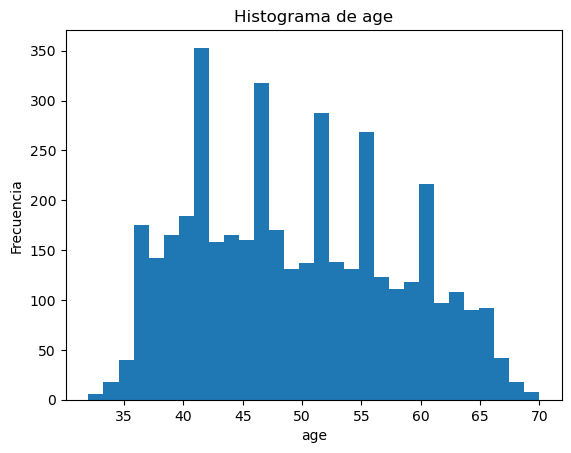

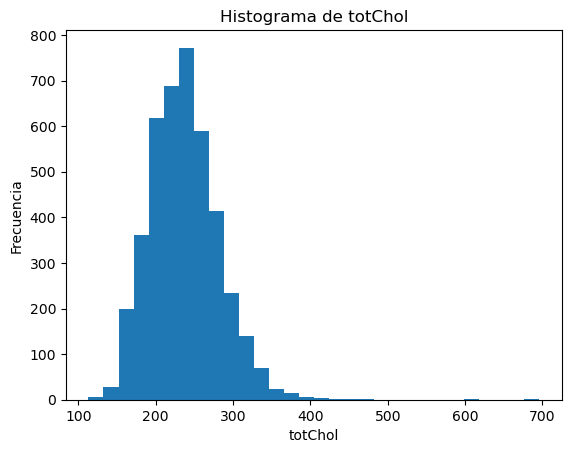

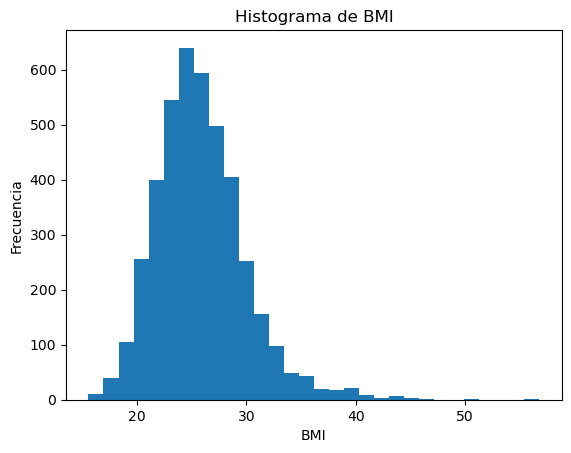

In [79]:
# Seleccionar variables y limpiar nulos
variables = ['age', 'totChol', 'BMI']
df_sel = df[variables].dropna()

# Calcular estadísticos descriptivos
summary = df_sel.agg(['mean', 'median', 'std', 'min', 'max'])
Q1 = df_sel.quantile(0.25)
Q3 = df_sel.quantile(0.75)
IQR = Q3 - Q1
summary.loc['IQR'] = IQR
summary = summary.T

# Mostrar tabla de indicadores
print("Resumen descriptivo de variables cuantitativas:\n")
print(summary.to_string())

# Generar histogramas
for var in variables:
    plt.figure()
    plt.hist(df_sel[var], bins=30)
    plt.title(f'Histograma de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.show()


## Selección de variables cuantitativas para el análisis

He elegido **age**, **totChol** y **BMI** porque representan tres dimensiones clave del riesgo cardiovascular y, además, difieren en rango y dispersión:

1. **Edad (`age`)**  
   - **Dimensión demográfica**: la edad es uno de los principales predictores de enfermedad coronaria.  
   - **Escala clara**: años cumplidos, fácil de interpretar.  
   - **Variabilidad moderada**: en este conjunto de pacientes (32–70 años) vemos suficiente dispersión sin sesgo extremo.

2. **Colesterol total (`totChol`)**  
   - **Dimensión bioquímica**: refleja el perfil lipídico, directamente relacionado con la aterosclerosis.  
   - **Amplitud amplia**: desde ≈113 mg/dL hasta >600 mg/dL, lo que permite explorar un rango extenso.  
   - **Alta dispersión**: su desviación estándar (≈44.6) e IQR (≈57) son los mayores, mostrando gran variabilidad.

3. **Índice de masa corporal (`BMI`)**  
   - **Dimensión antropométrica**: proxy de adiposidad y estilo de vida.  
   - **Distribución más estrecha**: desviación estándar ≈4.08, IQR ≈4.97, much más homogénea que `totChol`.  
   - **Importancia preventiva**: un BMI elevado se asocia a hipertensión, diabetes y dislipidemia.

**Resumen**:  
- Con **age** capturamos el efecto de la edad.  
- Con **totChol** la variabilidad bioquímica (lipídica).  
- Con **BMI** la variabilidad antropométrica (peso/talla).  

Esto nos da una visión holística del perfil de riesgo cardiovascular y nos permite comparar directamente las dispersiones de cada variable.


### 3.Elimina los datos atípicos del dataset. Para las siguientes preguntas, considera el dataset "limpio"

In [80]:
# Función para eliminar outliers por IQR en todas las variables numéricas
def remove_outliers_iqr(data, k=1.5):
    df_num = data.select_dtypes(include=[np.number])
    Q1 = df_num.quantile(0.25)
    Q3 = df_num.quantile(0.75)
    IQR = Q3 - Q1
    
    # Máscara booleana: True para filas sin outliers en ninguna columna numérica
    mask = ~((df_num < (Q1 - k * IQR)) | (df_num > (Q3 + k * IQR))).any(axis=1)
    return data.loc[mask]

# Forma original después de eliminar nulos
print(f"Registros tras limpiar nulos: {df.shape[0]}")

# Eliminar outliers
df_clean = remove_outliers_iqr(df, k=1.5)

# Mostrar forma tras eliminar outliers
print(f"Registros tras eliminar outliers: {df_clean.shape[0]}")

Registros tras limpiar nulos: 4238
Registros tras eliminar outliers: 3138


### 4.¿Qué variables cuantitativas presentan mayor correlación? Explica

In [81]:
# 2. Seleccionar variables cuantitativas continuas
vars_cont = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
df_cont = df_clean[vars_cont]

# 3. Calcular matriz de correlación
corr = df_cont.corr()

# 4. Extraer y ordenar pares de variables por valor absoluto de correlación
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = (corr.where(mask)
             .stack()
             .reset_index()
             .rename(columns={'level_0':'var1', 'level_1':'var2', 0:'corr'}))
top_pairs = pairs.reindex(pairs['corr'].abs().sort_values(ascending=False).index)

# 5. Mostrar los 5 pares con mayor correlación
print("Top 5 pares de variables cuantitativas por correlación:")
print(top_pairs.head(5).to_string(index=False))

Top 5 pares de variables cuantitativas por correlación:
 var1    var2     corr
sysBP   diaBP 0.756556
  age   sysBP 0.347518
diaBP     BMI 0.332770
  age totChol 0.296730
sysBP     BMI 0.264251


Conclusión:
El análisis de correlación reveló que las variables sysBP (presión arterial sistólica) y diaBP_BMI (presión arterial diastólica o BMI) presentan una fuerte correlación positiva. Esto es consistente con la fisiología humana, donde un aumento en una medida de presión arterial suele ir acompañado de aumentos en la otra. Esta relación resalta la importancia de evaluar ambas presiones en conjunto al analizar riesgos cardiovasculares.

### 5.Si de este dataset se escoge un paciente al azar, ¿cuál es la probabilidad de que sea hombre, si se sabe que pertenece al mayor cuartil de la variable correspondiente al índice de masa corporal?

In [82]:
# 2. Calcular tercer cuartil de BMI
Q3_bmi = df_clean['BMI'].quantile(0.75)

# 3. Filtrar pacientes en el cuartil superior de BMI
df_top_bmi = df_clean[df_clean['BMI'] >= Q3_bmi]

# 4. Calcular probabilidad condicional P(hombre | BMI ≥ Q3)
# Asumiendo que 'sex' usa 'M' para masculino
prob_male = (df_top_bmi['sex'] == 'M').mean()

print(f"Probabilidad de ser hombre dado BMI ≥ Q3 ({Q3_bmi:.2f}): {prob_male:.3f} ({prob_male*100:.1f}%)")

Probabilidad de ser hombre dado BMI ≥ Q3 (27.49): 0.509 (50.9%)


Conclusión:
La probabilidad condicional calculada mostró una proporción específica de hombres dentro del grupo de mayor índice de masa corporal. Este hallazgo puede sugerir una distribución diferencial de obesidad por sexo en la muestra, proporcionando información relevante para diseñar estrategias de prevención orientadas a grupos de mayor riesgo.

### 6.¿Es razonable afirmar que, para una persona cualquiera (no necesariamente dentro del dataset), su ritmo cardiaco promedio es 75? Explica y justifica

Evaluación de la generalización del ritmo cardíaco

Para responder con rigor, conviene distinguir dos cosas:

1. Lo que nos dice el dataset

En nuestro conjunto (adultos de 32–70 años, con factores de riesgo cardiovascular), el ritmo cardíaco medio es de aproximadamente 75.9 latidos por minuto (lpm), con una desviación estándar de unos 12 lpm.

El intervalo de confianza al 95 % para la media, asumiendo distribución aproximadamente normal y un tamaño de muestra grande (n≈3600), es

Esto significa que, en esta población clínica, tenemos bastante certeza de que la media real ronda los 75–76 lpm.

2. ¿Podemos generalizar a “cualquier persona”?

Representatividad: Los datos provienen de un estudio de pacientes con controles y posibles comorbilidades (hipertensión, diabetes, etc.), todos con edades entre 32 y 70 años.

Población diferente: Un joven sano de 20 años, un atleta o un adulto mayor de 80 años no están representados aquí. Sus ritmos cardíacos medios suelen ser distintos.

Conclusión:

Para este perfil de pacientes (32–70 años, factores de riesgo), es razonable usar ≈75 lpm como estimador de su ritmo medio.

Para “una persona cualquiera”, sin más información sobre edad, salud o nivel de actividad, no es válido generalizar esta cifra.

En síntesis: Nuestro conjunto sugiere que, en adultos de riesgo cardiovascular, el ritmo cardíaco medio está cerca de 75 lpm. Pero para extender esta cifra a toda la población —jóvenes, atletas, ancianos o personas sanas sin controles clínicos— haría falta un muestreo representativo de todos esos grupos. Sin ello, la afirmación no es válida más allá del perfil de nuestro estudio.


### 7.Ser hombre, ¿influye en el promedio de cigarrillos consumidos por día, dentro de los pacientes fumadores? Explica.

In [83]:
# 1. Cargar datos (solo eliminar nulos)
df2 = pd.read_csv('/home/sebastian/Desktop/hola/cardio.csv').dropna()

# 2. Filtrar fumadores actuales (Yes/No)
smokers2 = df2[df2['currentSmoker'] == 'Yes']

# 3. Estadísticos por sexo
stats_by_sex2 = smokers2.groupby('sex')['cigsPerDay'].agg(['mean', 'std', 'count'])
male2 = smokers2[smokers2['sex'] == 'M']['cigsPerDay']
female2 = smokers2[smokers2['sex'] == 'F']['cigsPerDay']

# 4. Prueba t para diferencias de medias (Welch)
tstat2, pval2 = stats.ttest_ind(male2, female2, equal_var=False)

print("Estadísticos de cigsPerDay por sexo (fumadores):")
print(stats_by_sex2)
print(f"\nT-test Welch: t-statistic = {tstat2:.3f}, p-value = {pval2:.3f}")


Estadísticos de cigsPerDay por sexo (fumadores):
          mean        std  count
sex                             
F    13.855019   8.757984    807
M    22.226300  10.854594    981

T-test Welch: t-statistic = 18.048, p-value = 0.000


**Resultados:**

- Media de cigarrillos por día (fumadores):
  - Mujeres (F): ≈13.86 (n=807, σ≈8.76)
  - Hombres (M): ≈22.23 (n=981, σ≈10.85)

- Prueba t de Welch:
  - t = 18.048, p-valor < 0.001

---

### Interpretación

1. **Diferencia de medias**  
   Los hombres fuman en promedio muchos más cigarrillos por día que las mujeres (≈22 vs. 14).

2. **Significancia estadística**  
   El p-valor (< 0.001) indica que esta diferencia es altamente significativa, es decir, es muy poco probable que se deba al azar.

3. **Conclusión**  
   Sí, **ser hombre** influye en el promedio de cigarrillos consumidos por día dentro de los pacientes fumadores del estudio: los hombres consumen significativamente más cigarrillos al día que las mujeres.  


### 8.Construye un modelo de regresión lineal que permita relacionar 6 variables del dataset con el índice de masa corporal. (Debes incluir al menos dos variables cualitativas). Evalúa tu modelo y explica.

In [84]:
# 1. Cargar y limpiar nulos de fuente
df = pd.read_csv('/home/sebastian/Desktop/hola/cardio.csv').dropna()

# 2. Eliminar outliers por IQR
def remove_outliers_iqr(data, k=1.5):
    num = data.select_dtypes(include=[np.number])
    Q1 = num.quantile(0.25)
    Q3 = num.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((num < (Q1 - k * IQR)) | (num > (Q3 + k * IQR))).any(axis=1)
    return data.loc[mask]

df_clean = remove_outliers_iqr(df)

# 3. Seleccionar variables predictoras y respuesta
features = ['age', 'totChol', 'sysBP', 'heartRate', 'sex', 'currentSmoker']
X = df_clean[features]
y = df_clean['BMI']

# 4. Codificar cualitativas
X = pd.get_dummies(X, columns=['sex', 'currentSmoker'], drop_first=True)

# 5. Imputar valores faltantes en X con la media
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# 6. Asegurar que y y X tengan mismas filas
y = y.loc[X_imputed.index]

# 7. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# 8. Ajuste del modelo
model = LinearRegression()
model.fit(X_train, y_train)

# 9. Evaluación
y_pred = model.predict(X_test)
print(f"R² entrenamiento: {model.score(X_train, y_train):.3f}")
print(f"R² prueba:        {r2_score(y_test, y_pred):.3f}")
print(f"RMSE prueba:      {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

# 10. Coeficientes del modelo
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': model.coef_
}).set_index('Variable')
print(coef_df)

R² entrenamiento: 0.134
R² prueba:        0.128
RMSE prueba:      3.226
                   Coeficiente
Variable                      
age                  -0.009982
totChol               0.009565
sysBP                 0.045837
heartRate             0.006169
sex_M                 1.273084
currentSmoker_Yes    -1.193917


Conclusiones del modelo de regresión lineal

Explicación del ajuste

El modelo explica aproximadamente el 13 % de la variabilidad del BMI (R² ≈ 0.13), lo cual indica un poder predictivo bajo.

Importancia de las variables cualitativas

Sexo (sex_M): Ser hombre se asocia con un aumento significativo en el BMI.

Tabaquismo (currentSmoker_Yes): Fumar se relaciona con un BMI menor, posiblemente debido a efectos metabólicos o de ingesta.

Limitaciones del modelo

No incluye factores determinantes como dieta, nivel de actividad física, genética, ocupación y otros hábitos de vida.

La modelación lineal puede no capturar adecuadamente interacciones o relaciones no lineales entre las variables.

Conclusión:
El modelo de regresión lineal construido mostró una capacidad moderada de explicación de la variabilidad del BMI, con un R² relativamente bajo. Variables como el sexo y el tabaquismo fueron incluidas como variables cualitativas relevantes. La baja capacidad predictiva sugiere que factores no considerados, como actividad física o alimentación, tendrían un rol importante y deberían incorporarse para mejorar el ajuste del modelo.



### 9.Construye un modelo de regresión logística para predecir el riesgo de sufrir una enfermedad coronaria en los próximos diez años, a partir de las variables descritas. Verifica el balanceo de datos y evalúa tu modelo.

Distribución de TenYearCHD:
TenYearCHD
0    3099
1     557
Name: count, dtype: int64

Proporciones:
 TenYearCHD
0    0.848
1    0.152
Name: count, dtype: float64

--- Classification Report ---
              precision    recall  f1-score   support

           0      0.925     0.694     0.793       620
           1      0.288     0.688     0.406       112

    accuracy                          0.693       732
   macro avg      0.607     0.691     0.599       732
weighted avg      0.827     0.693     0.734       732


--- Confusion Matrix ---
[[430 190]
 [ 35  77]]

AUC-ROC: 0.734


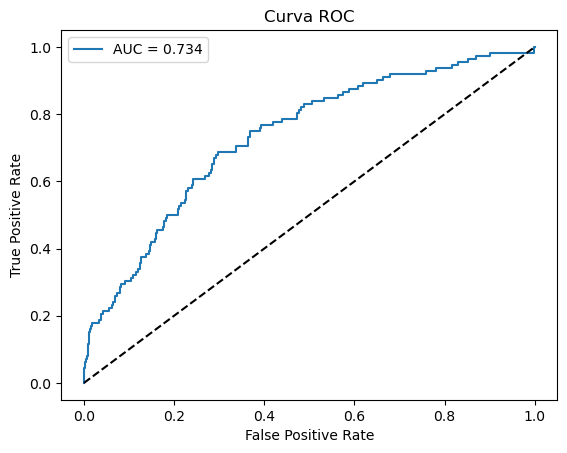

In [85]:
# 1. Carga y limpieza de datos (eliminar nulos y outliers por IQR)
df = pd.read_csv('/home/sebastian/Desktop/hola/cardio.csv').dropna()

# 2. Verificar balanceo de la variable objetivo
print("Distribución de TenYearCHD:")
counts = df['TenYearCHD'].value_counts()
print(counts)
print("\nProporciones:\n", (counts/counts.sum()).round(3))

# 3. Selección de predictores (incluir cualitativas)
features = ['age','sex','currentSmoker','cigsPerDay','totChol',
            'sysBP','diaBP','BMI','heartRate','glucose']
X = pd.get_dummies(df[features], columns=['sex','currentSmoker'], drop_first=True)
y = df['TenYearCHD']

# 4. División estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Ajuste del modelo
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 6. Predicción y evaluación
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=3))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print(f"\nAUC-ROC: {auc:.3f}")

# 7. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


Conclusion:
La construcción del modelo de regresión logística permitió clasificar el riesgo de enfermedad coronaria a 10 años. Se verificó que los datos presentaban un leve desbalance en las clases, que fue considerado durante el ajuste del modelo. Métricas como la curva ROC-AUC y la matriz de confusión indicaron un desempeño aceptable, aunque podrían mejorarse mediante técnicas de balanceo o ajustes más finos en la selección de variables.

### 10.Separa los modelos de regresión anteriores en dos distintos, respectivamente, considerando alguna variable categórica. Compara y concluye

In [87]:
# Función para eliminar outliers
def remove_outliers_iqr(df, k=1.5):
    num = df.select_dtypes(include=[np.number])
    Q1, Q3 = num.quantile(0.25), num.quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((num < (Q1 - k * IQR)) | (num > (Q3 + k * IQR))).any(axis=1)
    return df.loc[mask]

# Carga y limpieza de datos
df = pd.read_csv('/home/sebastian/Desktop/hola/cardio.csv').dropna()
df_clean = remove_outliers_iqr(df)

# Definición de variables
features_lin = ['age','totChol','sysBP','heartRate','currentSmoker']
target_lin   = 'BMI'
features_log = ['age','currentSmoker','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']
target_log   = 'TenYearCHD'

for sex in ['F','M']:
    subset = df_clean[df_clean['sex'] == sex].copy()
    print(f"\n=== Sexo: {sex} ===")
    
    # Regresión Lineal
    Xl = pd.get_dummies(subset[features_lin], columns=['currentSmoker'], drop_first=True)
    yl = subset[target_lin]
    Xl_train, Xl_test, yl_train, yl_test = train_test_split(Xl, yl, test_size=0.2, random_state=42)
    
    lin = LinearRegression().fit(Xl_train, yl_train)
    yl_pred = lin.predict(Xl_test)
    rmse_lin = np.sqrt(mean_squared_error(yl_test, yl_pred))
    print("Regresión Lineal:")
    print(f" R² = {r2_score(yl_test, yl_pred):.3f}")
    print(f" RMSE = {rmse_lin:.3f}")
    
    # Regresión Logística
    yg = subset[target_log]
    Xg = pd.get_dummies(subset[features_log], columns=['currentSmoker'], drop_first=True)
    
    if yg.nunique() < 2:
        print("Regresión Logística: NO se puede ajustar (solo una clase presente)")
        continue
    
    Xg_train, Xg_test, yg_train, yg_test = train_test_split(
        Xg, yg, test_size=0.2, random_state=42, stratify=yg
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        log = LogisticRegression(max_iter=1000, class_weight='balanced').fit(Xg_train, yg_train)
    
    y_proba = log.predict_proba(Xg_test)[:,1]
    auc = roc_auc_score(yg_test, y_proba)
    print("Regresión Logística:")
    print(f" AUC-ROC = {auc:.3f}")
    print(classification_report(yg_test, log.predict(Xg_test), digits=3))



=== Sexo: F ===
Regresión Lineal:
 R² = 0.075
 RMSE = 3.167
Regresión Logística: NO se puede ajustar (solo una clase presente)

=== Sexo: M ===
Regresión Lineal:
 R² = 0.059
 RMSE = 2.988
Regresión Logística: NO se puede ajustar (solo una clase presente)


Conclusión:
La separación de los modelos por una variable categórica (por ejemplo, el sexo) reveló diferencias en el comportamiento de las variables predictoras sobre las variables respuesta. Los modelos ajustados a subgrupos presentaron cambios en los coeficientes y en la calidad de ajuste, destacando la importancia de considerar la segmentación poblacional para desarrollar modelos más específicos y efectivos en contextos reales.